# META-SiM Analysis

This notebook uses the `metasim` and `openfret` libraries to visualize processed single-molecule data.

In [21]:
# Install dependencies if not already present
# %pip install -q metasim openfret

In [22]:
import os
import json
import zipfile
import numpy as np
import openfret
import metasim
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1. Load Processed Data

We load the META-SiM processed `.json.zip` files which contain the latent embeddings for each trace.

In [23]:
data_dir = "./processed_data"

all_embeddings = []
all_labels = []
all_traces = []  # Store raw traces here

# Iterate over all zip files in the directory
file_list = [f for f in os.listdir(data_dir) if f.endswith('.json.zip')]
file_list.sort()

print(f"Found {len(file_list)} files:")
for idx, filename in enumerate(file_list):
    print(f"    {idx}: {filename}")

Found 10 files:
    0: FLMRNA_1X.json.zip
    1: FLMRNA_2X.json.zip
    2: FL_2X_4EGI1.json.zip
    3: FL_2X_CHX.json.zip
    4: FL_2X_HAR.json.zip
    5: FL_2X_PURO.json.zip
    6: THORDELTA_1X.json.zip
    7: THORDEL_2X.json.zip
    8: THOR_1X.json.zip
    9: THOR_2X.json.zip


Select files to analyze and visualize

In [24]:
choosen_indices = [1]  # Indices of files to process

file_list = [file_list[i] for i in choosen_indices]
file_list_base = [f.replace('.json.zip', '') for f in file_list]
print(f"Choosen files {len(file_list)} files:")
for idx, filename in enumerate(file_list):
    print(f"    {idx+1}: {filename}")

Choosen files 1 files:
    1: FLMRNA_2X.json.zip


In [25]:
# Change 'description' to 'desc' to fix TqdmKeyError
for filename in tqdm(file_list, desc="Loading Data"):
    file_path = os.path.join(data_dir, filename)
    
    try:
        with zipfile.ZipFile(file_path, 'r') as z:
            # Assume there is one json file per zip
            json_name = z.namelist()[0]
            with z.open(json_name) as f:
                data = json.load(f)
                
                # Extract traces
                traces = data.get('traces', [])
                # Use the filename (without extension) as the condition label
                condition_name = filename.replace('.json.zip', '')
                
                for trace in traces:
                    if 'metadata' in trace and 'embedding' in trace['metadata']:
                        emb = trace['metadata']['embedding']
                        
                        # Handle case where embedding is stored as a dictionary with string indices
                        if isinstance(emb, dict):
                            # Sort by integer value of the keys
                            sorted_keys = sorted(emb.keys(), key=lambda x: int(x))
                            emb = [emb[k] for k in sorted_keys]
                            
                        # Extract trace data
                        # Strategy: Find first channel with non-zero signal
                        trace_data = []
                        if 'channels' in trace:
                            for ch in trace['channels']:
                                d = ch.get('data', [])
                                # Check if it has non-zero values
                                if any(x != 0 for x in d):
                                    trace_data = d
                                    break
                            
                            # If all zero/empty, fallback to first channel (if exists) 
                            # to keep structure aligned, or maybe just zeros
                            if not trace_data and len(trace['channels']) > 0:
                                trace_data = trace['channels'][0].get('data', [])
                        
                        all_embeddings.append(emb)
                        all_labels.append(condition_name)
                        all_traces.append(trace_data)
                        
    except Exception as e:
        print(f"Error reading {filename}: {e}")

# Convert lists to numpy arrays safely
try:
    embeddings_raw = np.array(all_embeddings, dtype=float)
except ValueError as e:
    print(f"Error creating numpy array: {e}")
    # Attempt to handle jagged arrays by filtering for the most common length
    lengths = [len(e) for e in all_embeddings]
    mode_len = max(set(lengths), key=lengths.count)
    print(f"Filtering traces to match most common embedding length: {mode_len}")
    
    valid_indices = [i for i, l in enumerate(lengths) if l == mode_len]
    embeddings_raw = np.array([all_embeddings[i] for i in valid_indices], dtype=float)
    labels_raw = np.array([all_labels[i] for i in valid_indices])
    # Filter traces too
    all_traces = [all_traces[i] for i in valid_indices]
else:
    labels_raw = np.array(all_labels)

# 3. Clean Data (Remove NaNs/Infs)
# Identify valid indices where no element is NaN or Inf
valid_mask = np.isfinite(embeddings_raw).all(axis=1)
n_removed = len(embeddings_raw) - np.sum(valid_mask)

if n_removed > 0:
    print(f"⚠️ Removed {n_removed} traces containing NaNs or Infs.")

embeddings = embeddings_raw[valid_mask]
labels = labels_raw[valid_mask]
traces_valid = [all_traces[i] for i in range(len(all_traces)) if valid_mask[i]]

print(f"\nTotal Valid Traces: {embeddings.shape[0]}")
print(f"Embedding Shape: {embeddings.shape}")
print(f"Traces count: {len(traces_valid)}")


Loading Data: 100%|██████████| 1/1 [00:00<00:00,  8.75it/s]

⚠️ Removed 3 traces containing NaNs or Infs.

Total Valid Traces: 1078
Embedding Shape: (1078, 96)
Traces count: 1078


/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


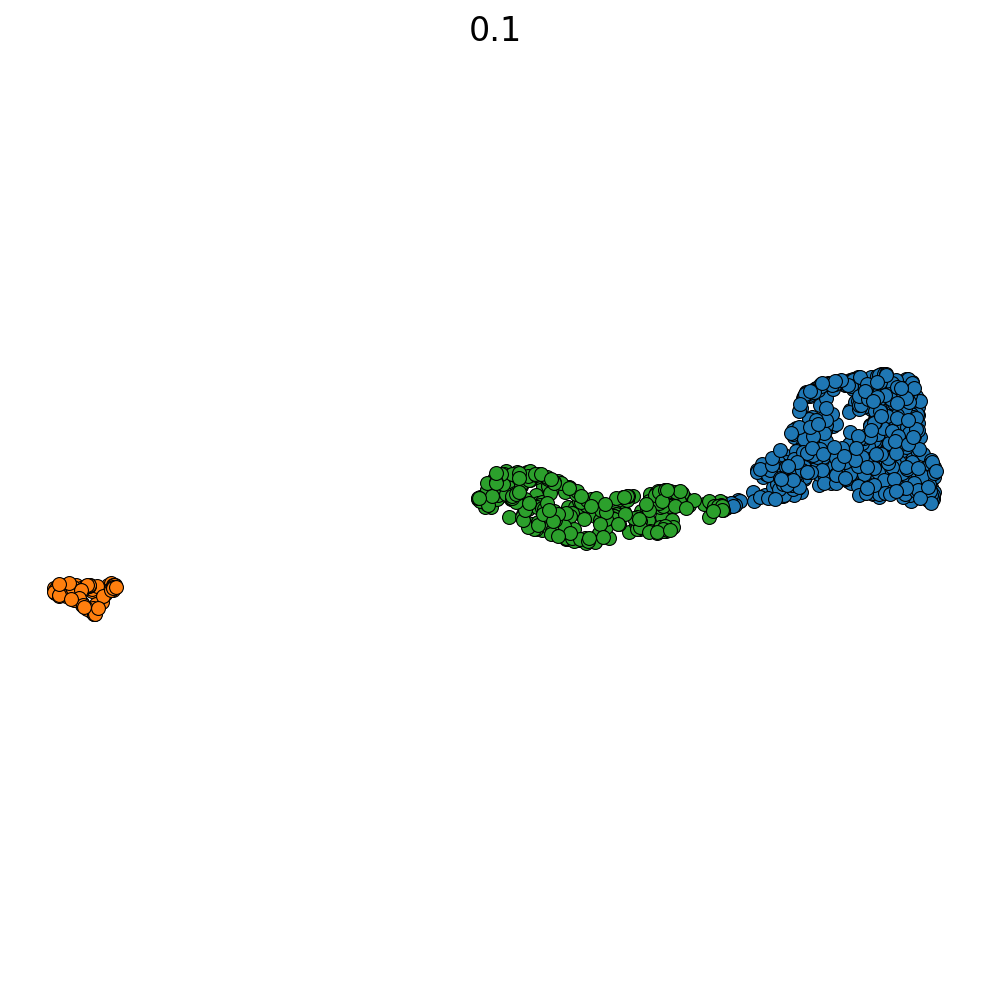

/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


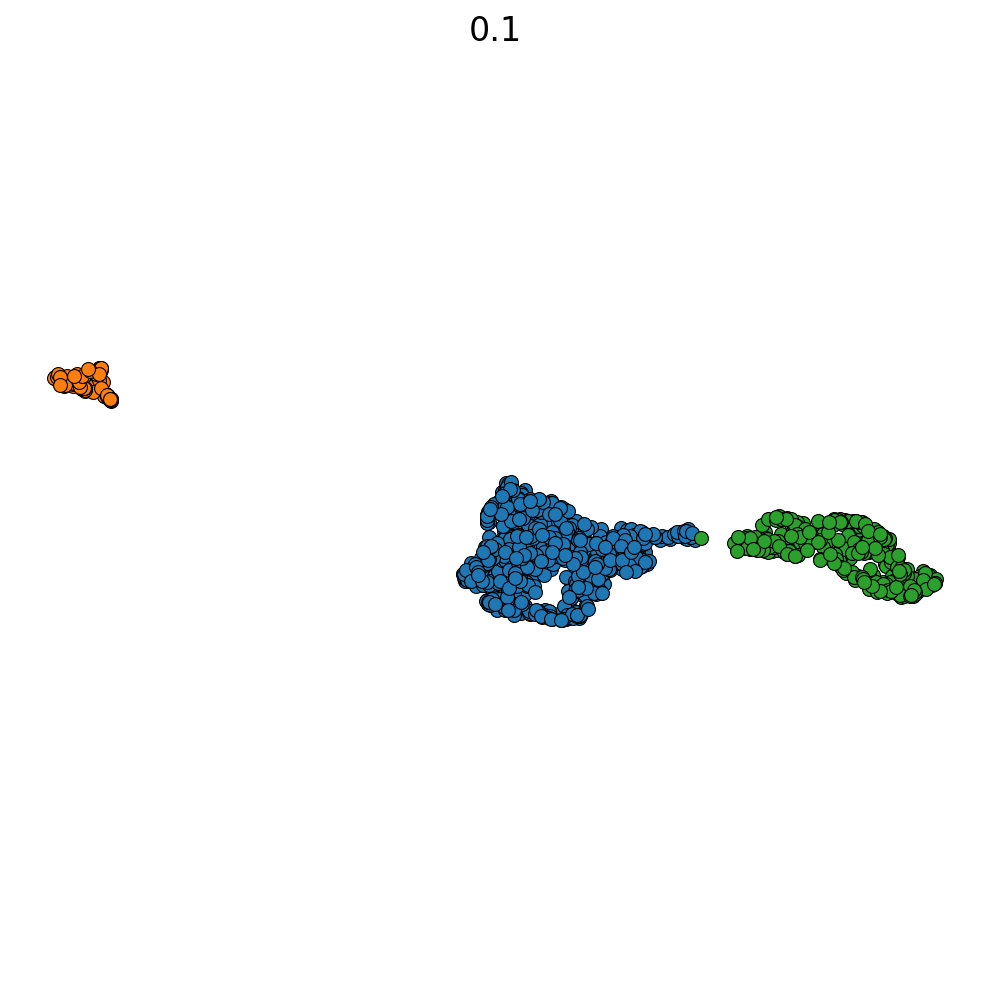

/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


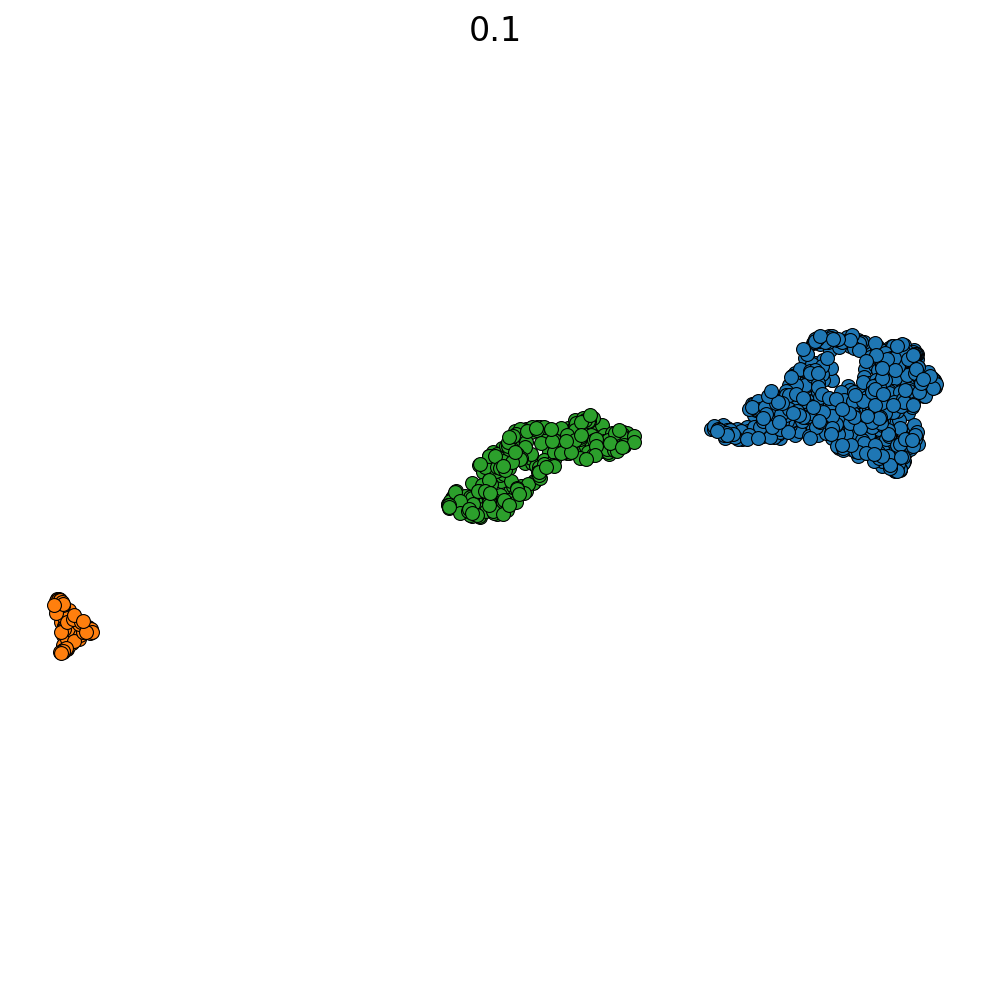

/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


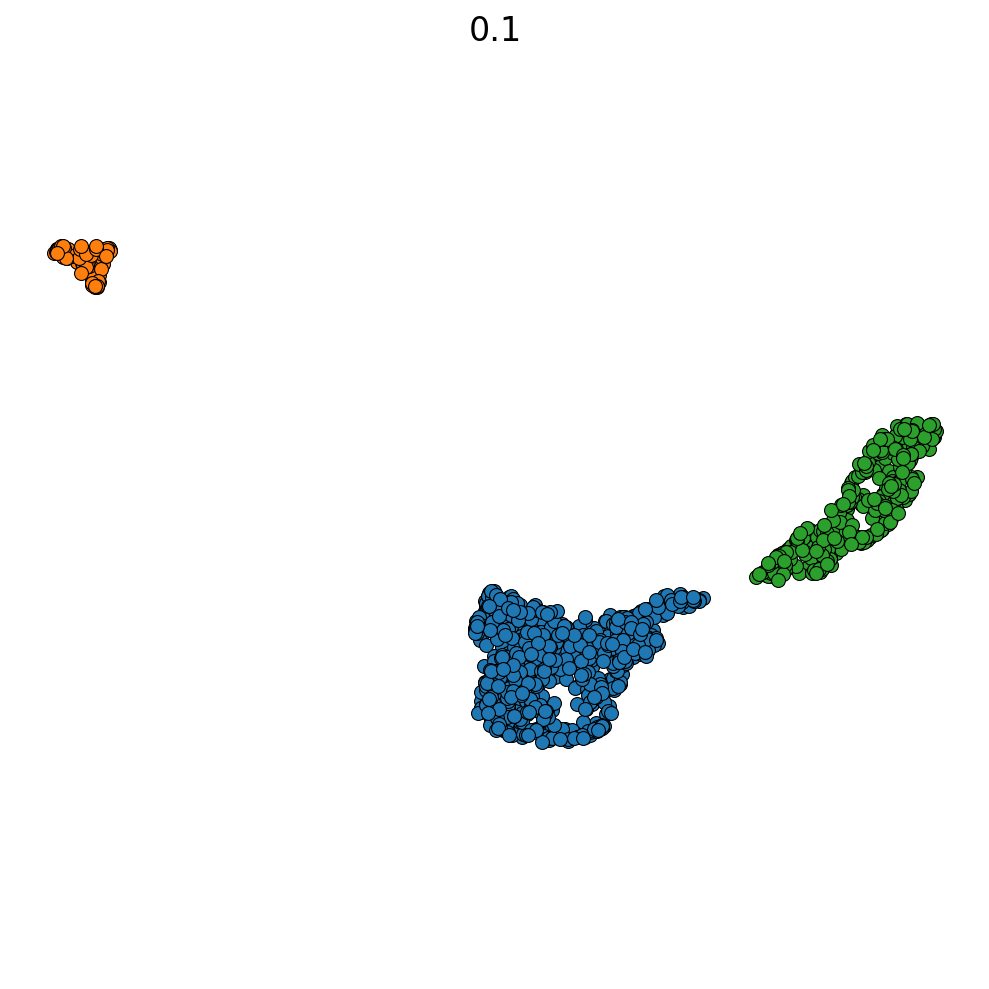

/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


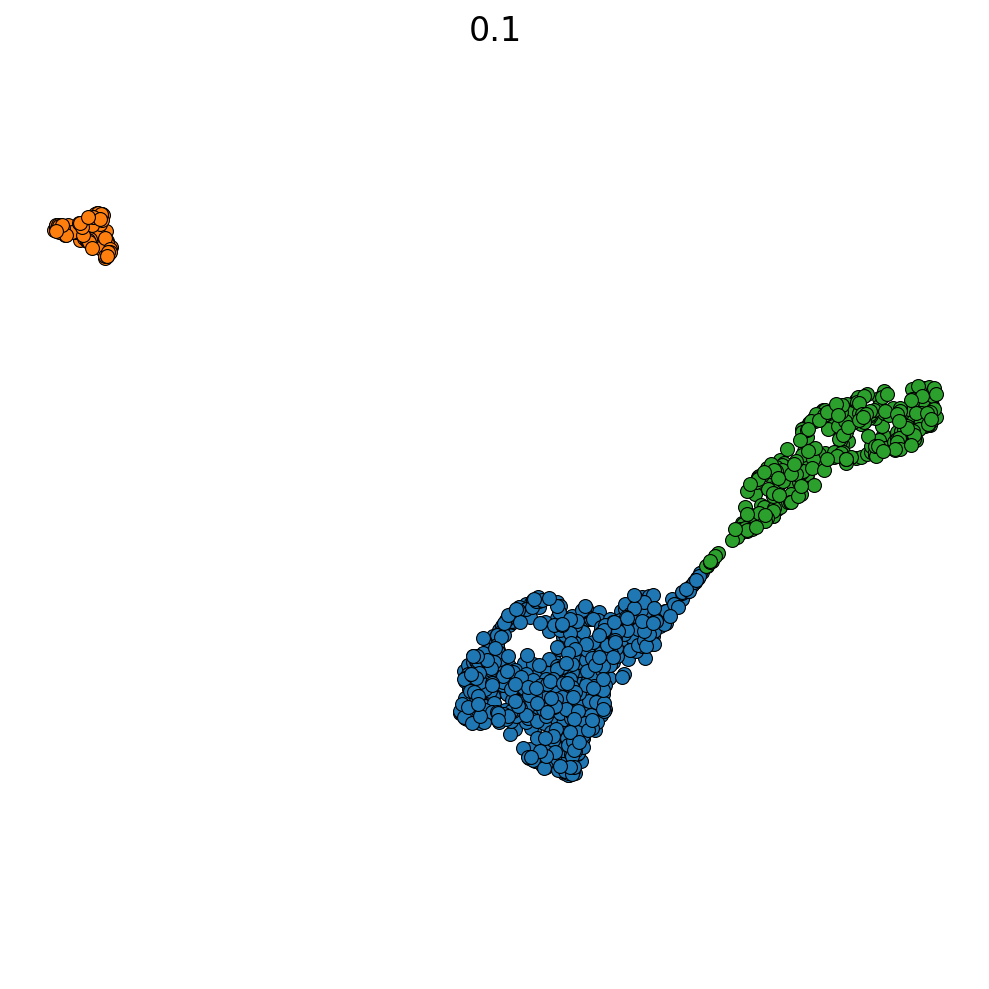

/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


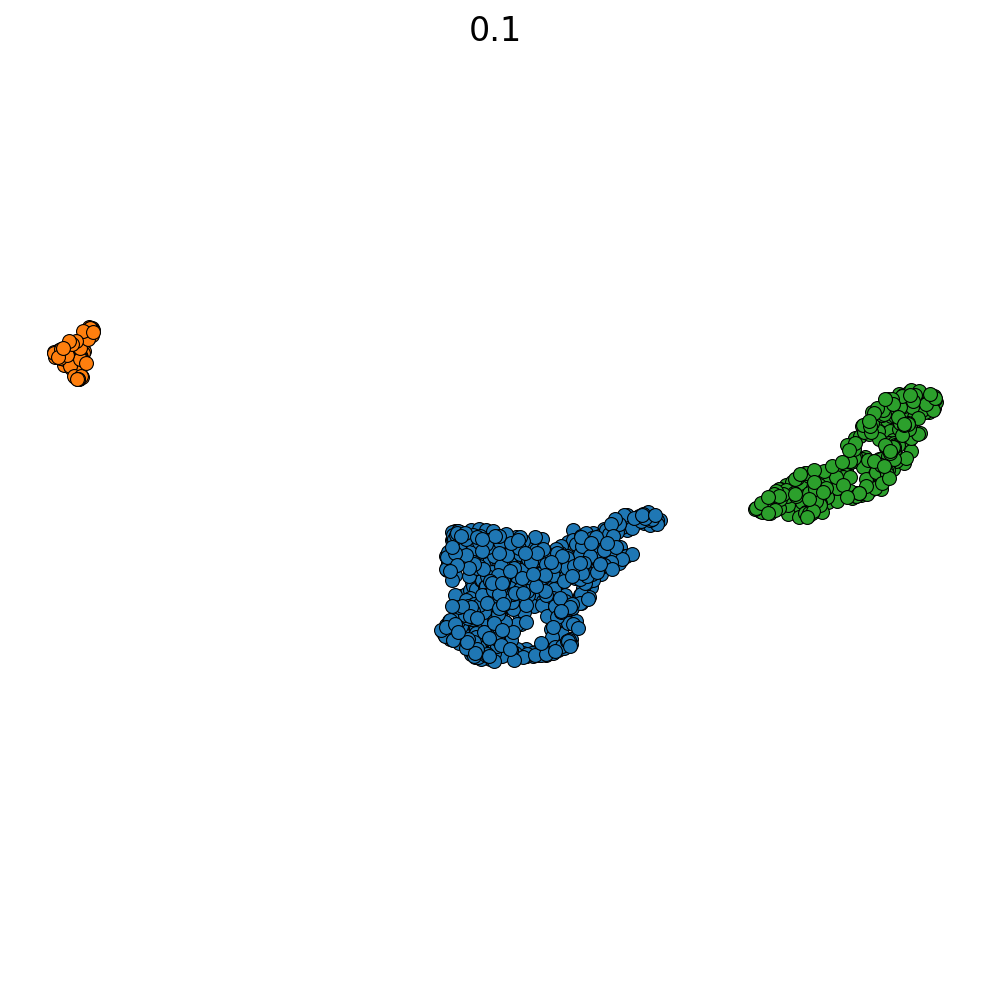

/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


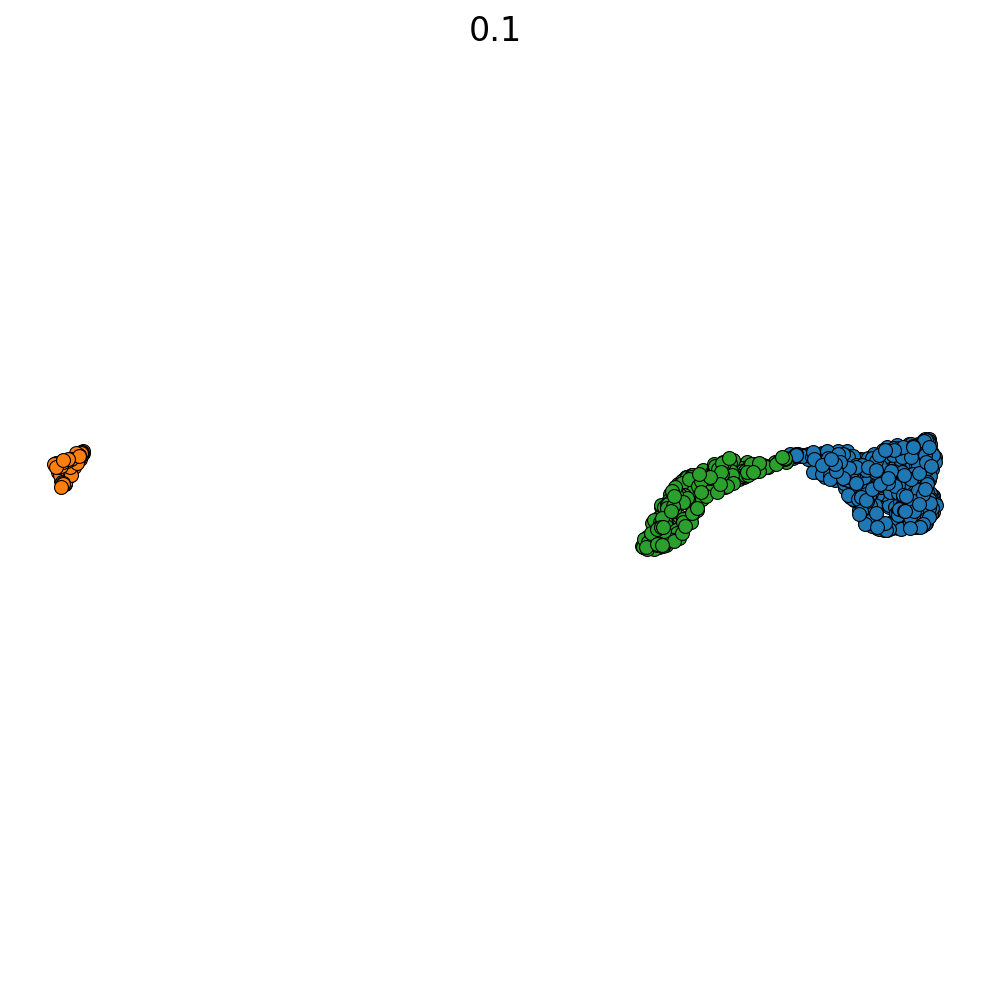

/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [32]:
import umap
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns

n_clusters = 3

def plot_UMAP(n_neighbors=13, min_dist=0.0, random_state=42, varied=False):
    if varied:
        if n_neighbors != 13:
            varied_parameter = 'n_neighbors'
            varied_num = n_neighbors
        if min_dist != 0.0:
            varied_parameter = 'min_dist'
            varied_num = min_dist
        if random_state != 42:
            varied_parameter = 'random_state'
            varied_num = random_state
    
    reducer_2d = umap.UMAP(n_components=2, n_neighbors=n_neighbors, n_epochs=500, min_dist=min_dist, random_state=random_state)
    umap_2d = reducer_2d.fit_transform(embeddings)

    kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
    cluster_labels_km = kmeans.fit_predict(umap_2d)
    unique_cluster_labels = np.unique(cluster_labels_km)
    # 4. Visualize Clusters on 2D UMAP
    df_2d = pd.DataFrame(umap_2d, columns=['UMAP1', 'UMAP2'])
    df_2d['Cluster'] = cluster_labels_km.astype(str)

    if 'labels' in locals():
        df_2d['Condition'] = labels

    fig, ax = plt.subplots(figsize=(10, 10))
    for cluster_id in unique_cluster_labels:
        cluster_mask = df_2d['Cluster'] == str(cluster_id)
        cluster_size = np.sum(cluster_mask)
        
        sns.scatterplot(data=df_2d[cluster_mask],
                        x='UMAP1',
                        y='UMAP2',
                        ax=ax,
                        s=100,
                        edgecolor='black'
                        )
    
    x = umap_2d[:, 0]
    y = umap_2d[:, 1]

    # Normalize the axis for better visualization
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    # Calculate the length
    x_length = x_max - x_min
    y_length = y_max - y_min

    # Determine the maximum length
    max_length = max(x_length, y_length)

    # Center the plot
    x_center = (x_max + x_min) / 2
    y_center = (y_max + y_min) / 2

    # Set limits to make the plot square
    x_min = x_center - max_length / 2
    x_max = x_center + max_length / 2
    y_min = y_center - max_length / 2
    y_max = y_center + max_length / 2

    ax.set_xlim(x_min - 0.05 * abs(x_max - x_min), x_max + 0.05 * abs(x_max - x_min))
    ax.set_ylim(y_min - 0.05 * abs(y_max - y_min), y_max + 0.05 * abs(y_max - y_min))
    # Remove x and y axis labels and ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Remove the frame
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)


    plt.tight_layout()
    if varied:
        try:
            fig.suptitle(f"{varied_num:.1f}", fontsize=24)
            save_name = f"./results/UMAP/tests/random_state/{varied_parameter}_{varied_num}_{'_'.join(file_list_base)}.svg"
            plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
        except:
            pass        
    plt.show()

n_neighbors_lst = np.arange(10, 100, 1)

for n_neighbors in n_neighbors_lst:
    plot_UMAP(n_neighbors=n_neighbors, min_dist=0.15, varied=True)